In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
#reading the csv file
df = pd.read_csv("D:/5 month Learning/Projects/911-calls-analytics/data/raw/911.csv")

In [71]:
#displaying top 5 entries
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [72]:
#information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


In [73]:
#statistics only for the numerical columns
df.describe()

,lat,lng,zip,e
count,99492.000000,99492.000000,86637.000000,99492.0
mean,40.159526,-75.317464,19237.658298,1.0
std,0.094446,0.174826,345.344914,0.0
min,30.333596,-95.595595,17752.000000,1.0
25%,40.100423,-75.392104,19038.000000,1.0
50%,40.145223,-75.304667,19401.000000,1.0
75%,40.229008,-75.212513,19446.000000,1.0
max,41.167156,-74.995041,77316.000000,1.0


In [74]:
#showing the columns names
df.columns

Index(['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e'], dtype='str')

# Timestamp Processing

In [75]:
type(df['timeStamp'])

pandas.Series

In [76]:
#choosing the timestamp column, and doing feature engineering on it, to convert it to date_time object
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

In [8]:
df['timeStamp'].head()

0   2015-12-10 17:40:00
1   2015-12-10 17:40:00
2   2015-12-10 17:40:00
3   2015-12-10 17:40:01
4   2015-12-10 17:40:01
Name: timeStamp, dtype: datetime64[us]

In [77]:
#accessing the first entry only for the column timestamp
df['timeStamp'].iloc[0]

Timestamp('2015-12-10 17:40:00')

In [78]:
type(df['timeStamp'].iloc[0])

pandas.Timestamp

In [11]:
t = df['timeStamp'].iloc[0]
t.dayofweek

3

In [12]:
#creating time based feature columns
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)


In [13]:
#converting weekdays number to names by creating a dictionary mapping
dmap = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}


In [14]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Hour,Month,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,17,12,3
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,17,12,3
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,17,12,3
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,17,12,3
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,17,12,3


In [15]:
df['Day of Week'] = df['Day of Week'].map(dmap)

In [16]:
df[['Day of Week','Hour','Month']].head()

,Day of Week,Hour,Month
0,Thu,17,12
1,Thu,17,12
2,Thu,17,12
3,Thu,17,12
4,Thu,17,12


# Extracting emergency category
** In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Using .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.** 

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS. **

In [17]:
#building the syntax to extract the category of emergency
df['title'].iloc[0].split(":")[0]

'EMS'

In [18]:
#creating a new column to specify the reason for calling emergency
df['Reason'] = df['title'].apply(lambda title: title.split(":")[0])

In [19]:
#What is the most common reason for calling 911, based on the new column
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

# Emergency Call Distribution

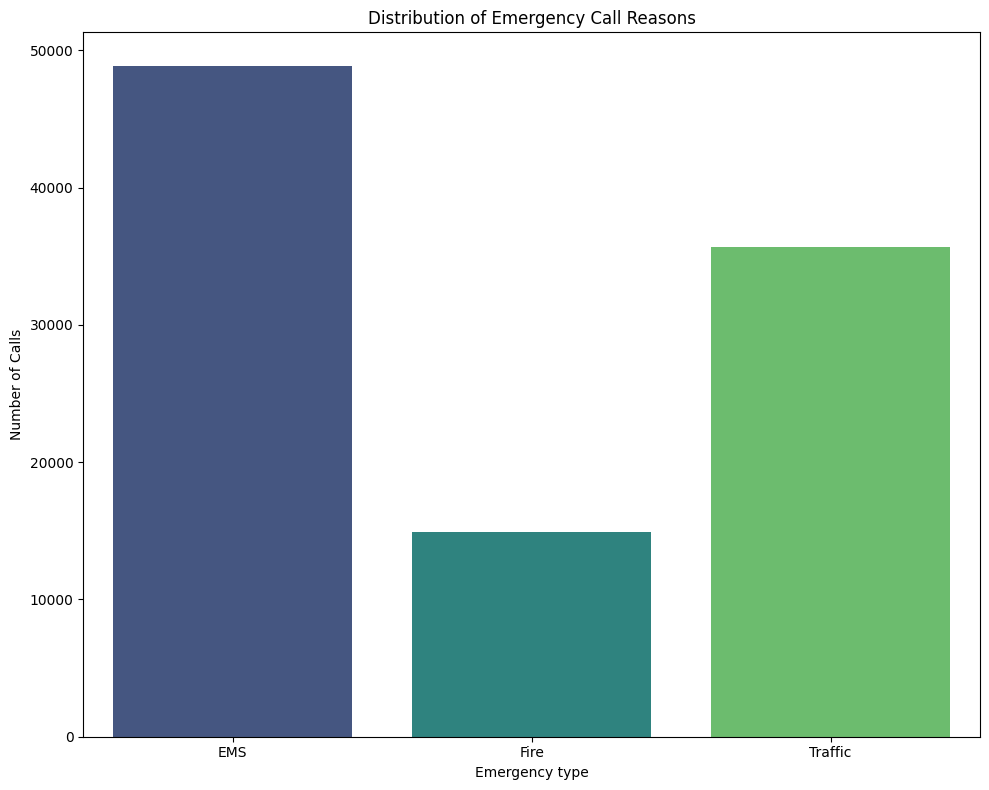

In [20]:
#Using seaborn to create a countplot of 911 calls by reason
plt.figure(figsize=(10,8))
sns.countplot(x = "Reason",hue ="Reason",data =df, palette='viridis')
plt.title("Distribution of Emergency Call Reasons")
plt.xlabel("Emergency type")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.savefig('D:/5 month Learning/Projects/911-calls-analytics/outputs/emergency_distribution.png')

The countplot shows that, "EMS" was the highest reason for calling 911, and "Traffic" being 2nd one reason for calling and significantly less calls came because of "Fire" reason

# Monthly call trends

In [ ]:
#group the data by month and aggregate their count
byMonth = df.groupby("Month").count()

In [23]:
byMonth.head(12)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Hour,Day of Week,Reason
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423
6,11786,11786,11786,10212,11786,11786,11777,11732,11786,11786,11786,11786
7,12137,12137,12137,10633,12137,12137,12133,12088,12137,12137,12137,12137
8,9078,9078,9078,7832,9078,9078,9073,9025,9078,9078,9078,9078
12,7969,7969,7969,6907,7969,7969,7963,7916,7969,7969,7969,7969


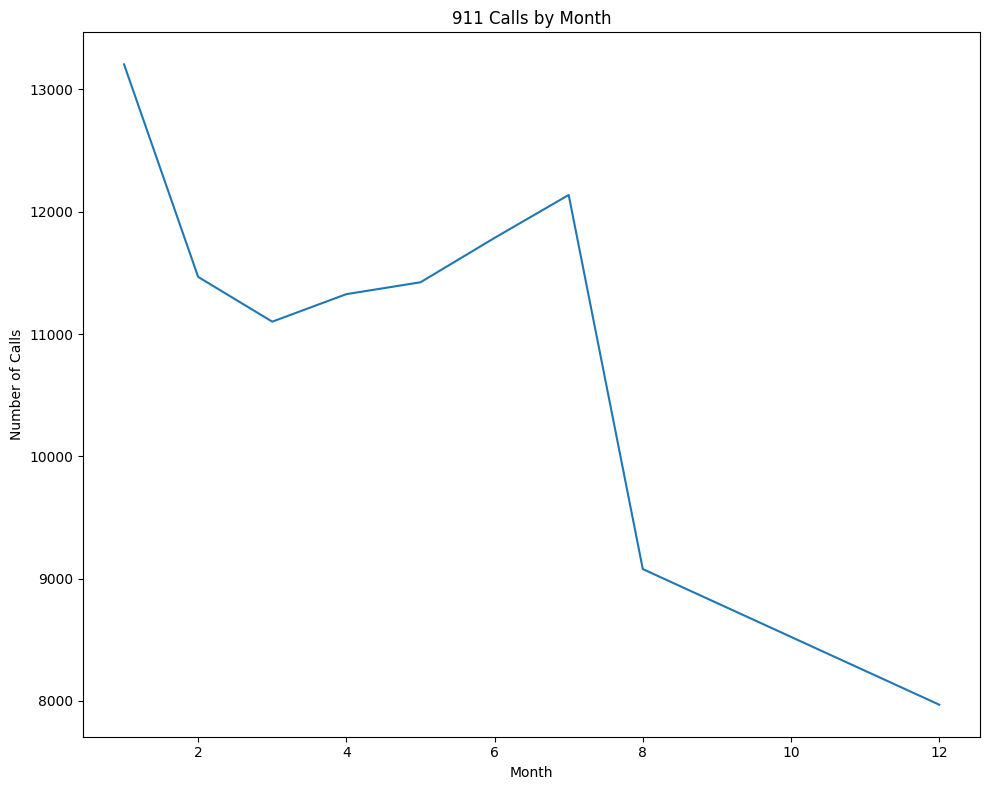

In [28]:
plt.figure(figsize = (10,8))
byMonth['lat'].plot()
plt.title('911 Calls by Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.tight_layout()
plt.savefig('D:/5 month Learning/Projects/911-calls-analytics/outputs/monthly_calls_trend.png')

The number of calls coming was the highest in month January, while it decreased till March and again increased till July but then there was a sharp decrease till December. Notable that, data for month 9,10,11 are not available.

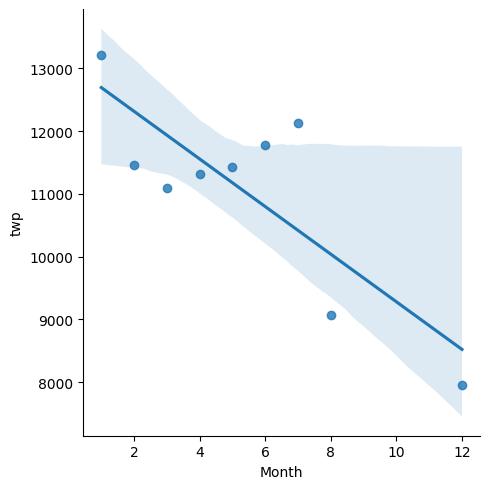

In [29]:
#adding a seaborn regression plot
sns.lmplot(x='Month', y='twp', data=byMonth.reset_index())

The regression line shows a downward trend of calls coming every month, which assures that the missing months (9,10,11) must be having less calls progressively.

# Date Feature engineering

In [ ]:
#from timestamp column extracting the date only
df['timeStamp'].iloc[0].date()

datetime.date(2015, 12, 10)

In [33]:
df['Date']=df['timeStamp'].apply(lambda t: t.date())

In [37]:
#displaying top entries for only 2 selected columns,passing a list of column
df[['timeStamp','Date']].head()

,timeStamp,Date
0,2015-12-10 17:40:00,2015-12-10
1,2015-12-10 17:40:00,2015-12-10
2,2015-12-10 17:40:00,2015-12-10
3,2015-12-10 17:40:01,2015-12-10
4,2015-12-10 17:40:01,2015-12-10


In [38]:
byDate=df.groupby('Date').count()

In [51]:
byDate.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Hour,Month,Day of Week,Reason
Date,,,,,,,,,,,,,
2015-12-10,115,115,115,100,115,115,115,113,115,115,115,115,115
2015-12-11,396,396,396,333,396,396,395,391,396,396,396,396,396
2015-12-12,403,403,403,333,403,403,403,401,403,403,403,403,403
2015-12-13,319,319,319,280,319,319,319,317,319,319,319,319,319
2015-12-14,447,447,447,387,447,447,446,445,447,447,447,447,447


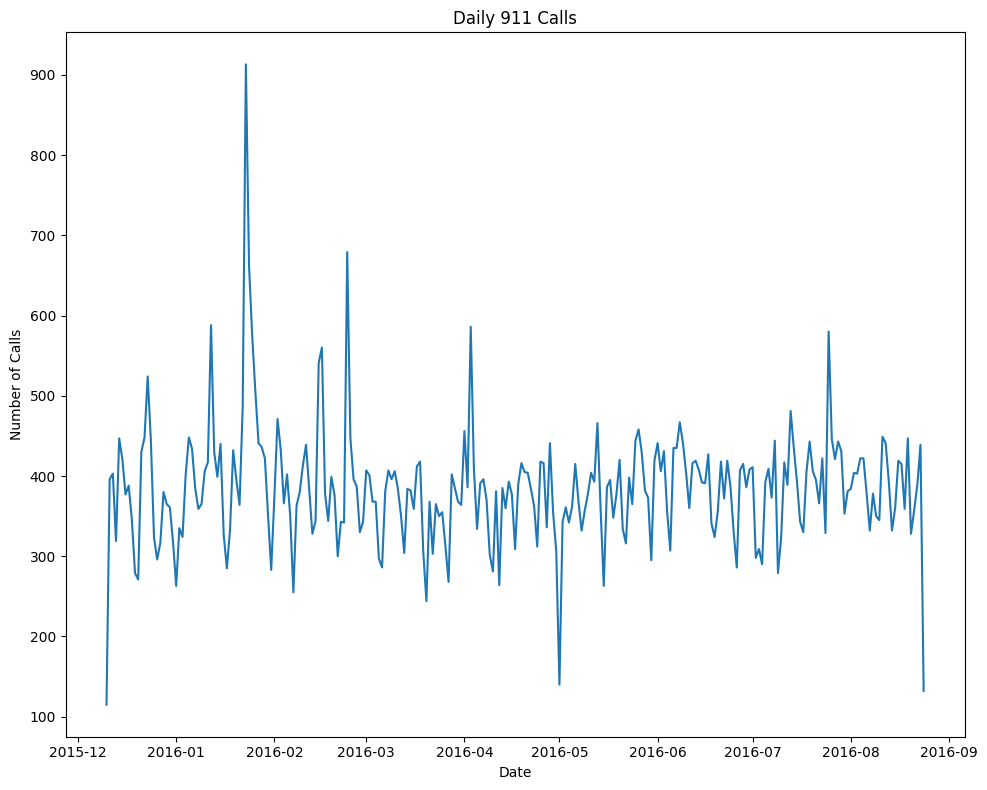

In [40]:
plt.figure(figsize=(10,8))
byDate['lat'].plot()
plt.title('Daily 911 Calls')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.tight_layout()
plt.savefig('D:/5 month Learning/Projects/911-calls-analytics/outputs/daily_calls_timeseries.png')

The plot shows the number of calls coming per day(according to date), which shows a abnormal peak of around 900 calls at the end of January of 2016. 

# Category Specific Calls(EMS, Fire or Traffic)

In [ ]:
#from data filtering only the calls that came because of EMS, then groupby Date and count.
df[df["Reason"] == "EMS"].groupby('Date').count()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Hour,Month,Day of Week,Reason
Date,,,,,,,,,,,,,
2015-12-10,57,57,57,52,57,57,57,57,57,57,57,57,57
2015-12-11,186,186,186,166,186,186,186,186,186,186,186,186,186
2015-12-12,189,189,189,171,189,189,189,189,189,189,189,189,189
2015-12-13,190,190,190,178,190,190,190,190,190,190,190,190,190
2015-12-14,222,222,222,201,222,222,222,222,222,222,222,222,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-08-20,159,159,159,139,159,159,159,159,159,159,159,159,159
2016-08-21,165,165,165,144,165,165,165,165,165,165,165,165,165
2016-08-22,182,182,182,163,182,182,182,182,182,182,182,182,182


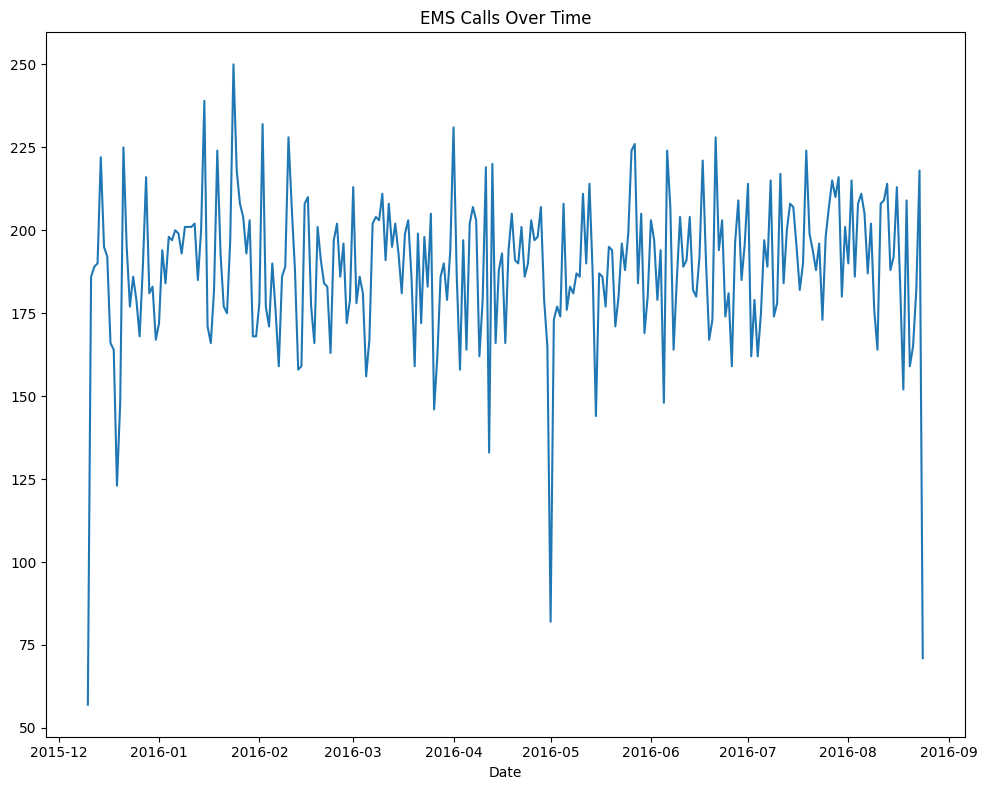

In [54]:
#plotting the number calls that came because of the reason of EMS
plt.figure(figsize=(10,8))
df[df["Reason"] == "EMS"].groupby('Date').count()['lat'].plot()
plt.title('EMS Calls Over Time')

plt.tight_layout()

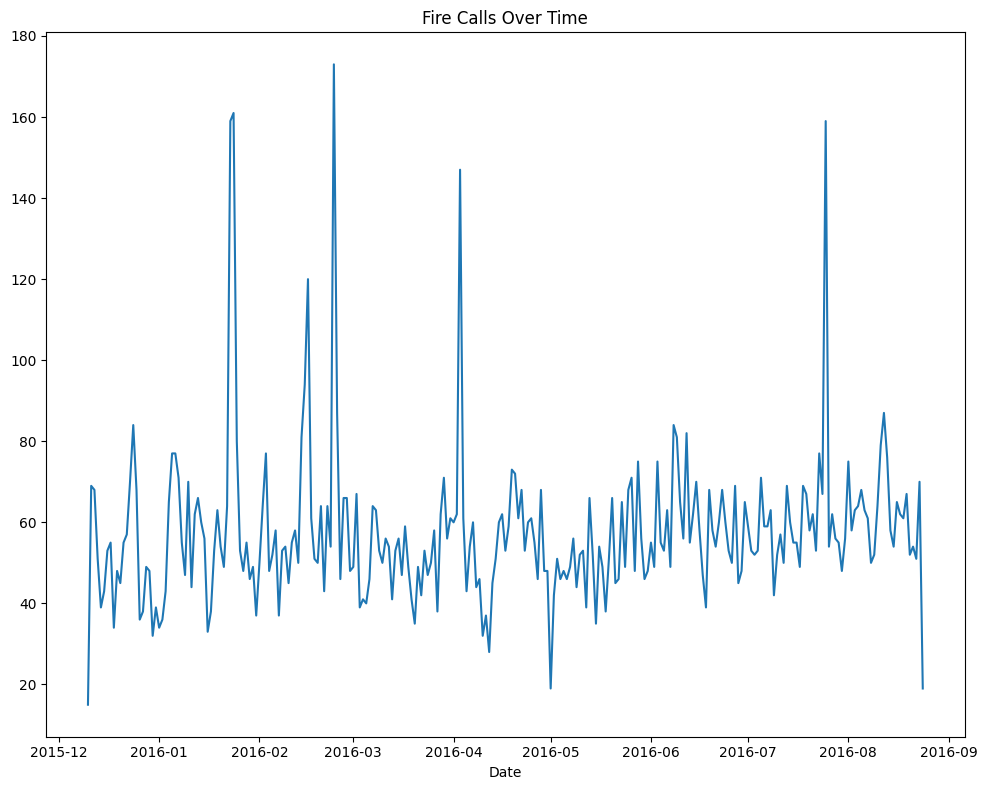

In [55]:
#plotting the number calls that came because of the reason of FIRE
plt.figure(figsize=(10,8))
df[df["Reason"] == "Fire"].groupby('Date').count()['lat'].plot()
plt.title('Fire Calls Over Time')

plt.tight_layout()

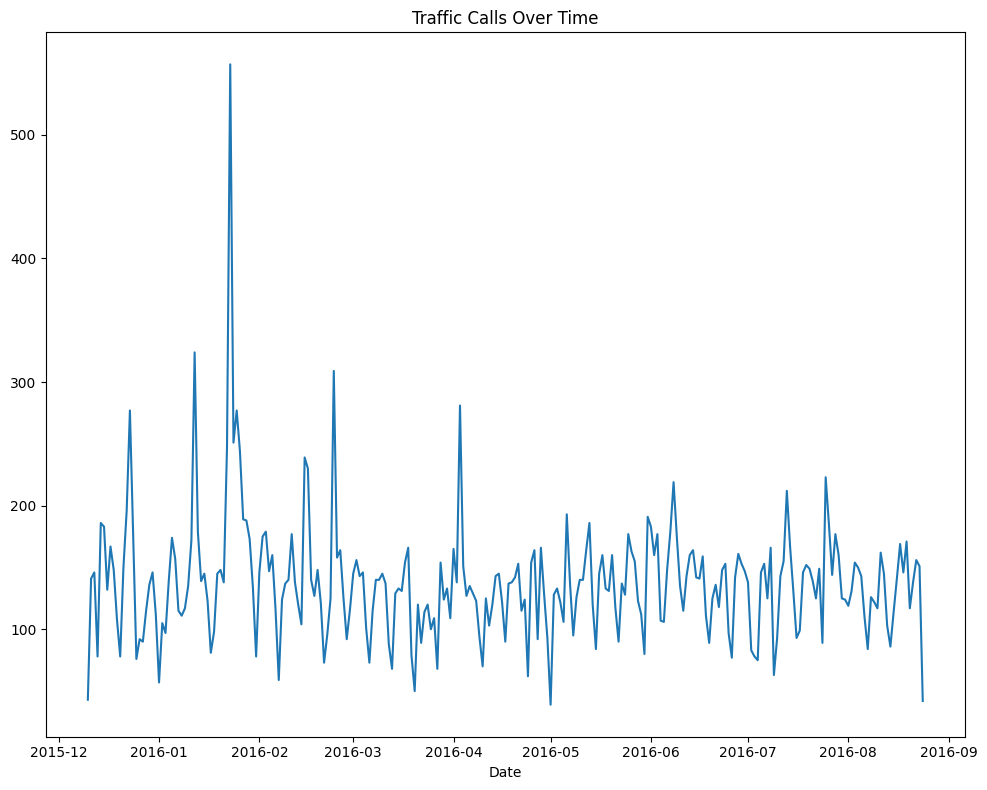

In [56]:
#plotting the number calls that came because of the reason of Traffic
plt.figure(figsize=(10,8))
df[df["Reason"] == "Traffic"].groupby('Date').count()['lat'].plot()
plt.title('Traffic Calls Over Time')

plt.tight_layout()

# Heatmap visualization

In [64]:
#groupby using both Daysofweek and Hour, creating a multiindex dataframe
df.groupby(by=['Day of Week', 'Hour']).count()


lat  lng  desc  zip  title  timeStamp  twp  addr    e  \
Day of Week Hour                                                          
Fri         0     275  275   275  248    275        275  275   275  275   
            1     235  235   235  200    235        235  235   232  235   
            2     191  191   191  165    191        191  191   191  191   
            3     175  175   175  164    175        175  175   175  175   
            4     201  201   201  184    201        201  201   201  201   
...               ...  ...   ...  ...    ...        ...  ...   ...  ...   
Wed         19    686  686   686  590    686        686  686   682  686   
            20    668  668   668  597    668        668  668   662  668   
            21    575  575   575  508    575        575  574   572  575   
            22    490  490   490  432    490        490  490   485  490   
            23    335  335   335  294    335        335  334   335  335   

                  Month  Reason  Date  
Day of Week Hour                       
Fri         0       275     275   275  
            1       235     235   235  
            2       191     191   191  
            3       175     175   175  
            4       201     201   201  
...                 ...     ...   ...  
Wed         19      686     686   686  
            20      668     668   668  
            21      575     575   575  
            22      490     490   490  
            23      335     335   335  

[168 rows x 12 columns]

In [67]:
#only fetching the Reason column, applying unstack to give a matrix format
df.groupby(by=['Day of Week', 'Hour']).count()['Reason'].unstack()

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


In [68]:
dayHour = df.groupby(by=['Day of Week', 'Hour']).count()['Reason'].unstack()
dayHour.head()

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354


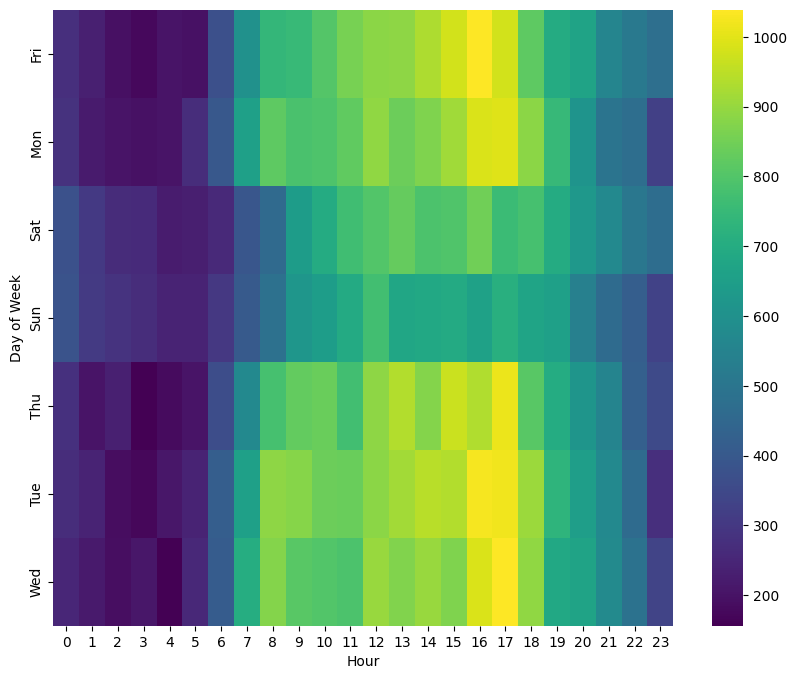

In [69]:
#Heatmaps of Calls by Day and Hour
plt.figure(figsize=(10,8))
sns.heatmap(dayHour, cmap = 'viridis')
plt.savefig('D:/5 month Learning/Projects/911-calls-analytics/outputs/day_hour_heatmap.png')


Heatmap shows that the calls were sigficantly more around the Hours(16-17) while very less number of calls (0-6 Hours) and in the Weekends(Saturday and Sunday) there is comparatively less calls than the Weekdays.